#Homework 6: Decision Transformer with Memory

In [ ]:
!unzip /content/Decision-Transformer-with-Memory-for-POMDPs-main.zip

Archive:  /content/Decision-Transformer-with-Memory-for-POMDPs-main.zip
5c7df5b78ebc6493584e83526533462305bb5817
   creating: Decision-Transformer-with-Memory-for-POMDPs-main/
  inflating: Decision-Transformer-with-Memory-for-POMDPs-main/.gitignore  
  inflating: Decision-Transformer-with-Memory-for-POMDPs-main/LICENSE  
  inflating: Decision-Transformer-with-Memory-for-POMDPs-main/README.md  
  inflating: Decision-Transformer-with-Memory-for-POMDPs-main/memory_dt.py  
   creating: Decision-Transformer-with-Memory-for-POMDPs-main/pomdp_envs/
  inflating: Decision-Transformer-with-Memory-for-POMDPs-main/pomdp_envs/flickering_pendulum.py  
  inflating: Decision-Transformer-with-Memory-for-POMDPs-main/pomdp_envs/lidar_mountain_car.py  
  inflating: Decision-Transformer-with-Memory-for-POMDPs-main/pomdp_envs/velocity_cartpole.py  
  inflating: Decision-Transformer-with-Memory-for-POMDPs-main/recurrent_ppo.py  
  inflating: Decision-Transformer-with-Memory-for-POMDPs-main/run_memory_dt.py  

In [ ]:
!mv /content/Decision-Transformer-with-Memory-for-POMDPs-main/* /content/

In [ ]:
!pip install torch numpy matplotlib gymnasium tqdm

## Создание датасета

In [ ]:
!python train_and_collect_data.py --env velocity_cartpole --train_timesteps 300000 --num_trajectories 100 --reward_threshold 475


Выходные данные были обрезаны до нескольких последних строк (5000).
Episode 255, reward: 20.00, avg_reward (last 50): 23.92, timesteps: 5734/300000
Episode 256, reward: 104.00, avg_reward (last 50): 25.74, timesteps: 5838/300000
New best model saved with reward: 104.0
Episode 257, reward: 32.00, avg_reward (last 50): 26.04, timesteps: 5870/300000
Episode 258, reward: 11.00, avg_reward (last 50): 25.44, timesteps: 5881/300000
Episode 259, reward: 27.00, avg_reward (last 50): 24.80, timesteps: 5908/300000
Episode 260, reward: 49.00, avg_reward (last 50): 24.96, timesteps: 5957/300000
Episode 261, reward: 26.00, avg_reward (last 50): 25.20, timesteps: 5983/300000
Episode 262, reward: 50.00, avg_reward (last 50): 25.50, timesteps: 6033/300000
Episode 263, reward: 55.00, avg_reward (last 50): 26.02, timesteps: 6088/300000
Episode 264, reward: 30.00, avg_reward (last 50): 25.86, timesteps: 6118/300000
Episode 265, reward: 36.00, avg_reward (last 50): 25.40, timesteps: 6154/300000
Episode 266

In [ ]:
!python utils/visualize_ppo_agent.py --env velocity_cartpole --model_path pomdp_datasets/velocity_cartpole/recurrent_ppo_velocity_cartpole.pt --rnn_type gru


Visualization of velocity_cartpole from pomdp_datasets/velocity_cartpole/recurrent_ppo_velocity_cartpole.pt
RNN type: gru, Hidden dim: 128
error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default

Episode 1/5
Step 1: Action=1, Value=66.308
Step 2: Action=1, Value=66.309
Step 3: Action=1, Value=66.308
Step 4: Action=0, Value=66.307
St

In [ ]:
!python memory_dt.py --dataset pomdp_datasets/velocity_cartpole --stats_only


Analyzing 100 trajectories files in pomdp_datasets/velocity_cartpole
100% 100/100 [00:00<00:00, 2980.86it/s]

Dataset statistics:
Total episodes: 100
Total steps: 49871
Mean reward per episode: 498.71
Median reward per episode: 500.00
Min/Max reward: 475.00/500.00
Reward std: 4.70
Mean episode length: 498.71
Reward percentiles: 
  10%: 499.90
  25%: 500.00
  50%: 500.00
  75%: 500.00
  90%: 500.00
  95%: 500.00
  99%: 500.00
Saved histogram to plots/velocity_cartpole_rewards_histogram.png


## Тренировка и валидация DT, DT+LSTM, DT+GRU

In [ ]:
!python run_memory_dt.py --env velocity_cartpole --memory_type none --n_epochs 7 --eval_episodes 20 2>&1 | tee train_baseline.log

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49811, train=44829, val=4982, state_dim=2, actions=2
Epoch 1/7 [Train]: 100%|██████████| 701/701 [03:29<00:00,  3.34it/s, loss=0.5110, avg_loss=0.5444, lr=0.000994]
Epoch 1/7: Train Loss=0.5444, Val Loss=0.4961
Running environment validation...
Episode 1: Return=90.0, Steps=90
Episode 2: Return=63.0, Steps=63
Episode 3: Return=83.0, Steps=83
Episode 4: Return=48.0, Steps=48
Episode 5: Return=12.0, Steps=12
Episode 6: Return=160.0, Steps=160
Episode 7: Return=105.0, Steps=105
Episode 8: Return=40.0, Steps=40
Episode 9: Return=13.0, Steps=13
Episode 10: Return=160.0, Steps=160
Validation: Mean Return=77.40, Success Rate=0.00%
New best model with return 77.40
Epoch 2/7 [Train]: 100%|██████████| 701/701 [03:29<00:00,  3.35it/s, loss=0.4966, avg_loss=0.4972, lr=0.000898]
Epoch 2/7: Train Loss=0.4972, Val Loss=0.4871
Running environment validation...
Episode 1: Return=131.0, Steps=131
Episode 2: Return=84.0, St

In [ ]:
!python utils/visualize_dt_agent.py --env velocity_cartpole --model_path models/memory_dt_velocity_cartpole_None_best.pt --memory_type none 2>&1 | tee val_baseline.log


error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
Model parameters: n_embed=64, n_layer=3, n_head=4, memory_dim=64
action_head structure: Linear
Visualizing velocity_cartpole agent from models/memory_dt_velocity_cartpole_None_best.pt
Memory type: none, Context length: 20

Episode 1/5
Target return: 500.0
Step 1: Initial action

In [ ]:
# Train DT+GRU (0.1 points)
!python run_memory_dt.py --env velocity_cartpole --memory_type gru --n_epochs 7 --eval_episodes 20 2>&1 | tee gru_train_baseline.log

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49811, train=44829, val=4982, state_dim=2, actions=2
Epoch 1/7 [Train]: 100%|██████████| 701/701 [03:39<00:00,  3.20it/s, loss=0.4611, avg_loss=0.5400, lr=0.000994]
Epoch 1/7: Train Loss=0.5400, Val Loss=0.4887
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Episode 6: Return=500.0, Steps=500
Episode 7: Return=500.0, Steps=500
Episode 8: Return=500.0, Steps=500
Episode 9: Return=500.0, Steps=500
Episode 10: Return=500.0, Steps=500
Validation: Mean Return=500.00, Success Rate=100.00%
New best model with return 500.00
Epoch 2/7 [Train]: 100%|██████████| 701/701 [03:40<00:00,  3.18it/s, loss=0.4701, avg_loss=0.4820, lr=0.000898]
Epoch 2/7: Train Loss=0.4820, Val Loss=0.4781
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 

In [ ]:
# Validate DT+GRU
!python utils/visualize_dt_agent.py --env velocity_cartpole --model_path models/memory_dt_velocity_cartpole_gru_best.pt --memory_type gru 2>&1 | tee gru_val_baseline.log


error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
Model parameters: n_embed=64, n_layer=3, n_head=4, memory_dim=64
action_head structure: Linear
Visualizing velocity_cartpole agent from models/memory_dt_velocity_cartpole_gru_best.pt
Memory type: gru, Context length: 20

Episode 1/5
Target return: 500.0
Step 1: Initial action=0

In [ ]:
# Train DT+LSTM (0.1 points)
!python run_memory_dt.py --env velocity_cartpole --memory_type lstm --n_epochs 7 --eval_episodes 20 2>&1 | tee lstm_train_baseline.log

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49811, train=44829, val=4982, state_dim=2, actions=2
Epoch 1/7 [Train]: 100%|██████████| 701/701 [03:39<00:00,  3.19it/s, loss=0.4739, avg_loss=0.5502, lr=0.000994]
Epoch 1/7: Train Loss=0.5502, Val Loss=0.4999
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: Return=500.0, Steps=500
Episode 3: Return=500.0, Steps=500
Episode 4: Return=500.0, Steps=500
Episode 5: Return=500.0, Steps=500
Episode 6: Return=500.0, Steps=500
Episode 7: Return=500.0, Steps=500
Episode 8: Return=500.0, Steps=500
Episode 9: Return=500.0, Steps=500
Episode 10: Return=500.0, Steps=500
Validation: Mean Return=500.00, Success Rate=100.00%
New best model with return 500.00
Epoch 2/7 [Train]: 100%|██████████| 701/701 [03:41<00:00,  3.16it/s, loss=0.4557, avg_loss=0.4838, lr=0.000898]
Epoch 2/7: Train Loss=0.4838, Val Loss=0.4792
Running environment validation...
Episode 1: Return=191.0, Steps=191
Episode 

In [ ]:
# Validate DT+LSTM
!python utils/visualize_dt_agent.py --env velocity_cartpole --model_path models/memory_dt_velocity_cartpole_lstm_best.pt --memory_type lstm 2>&1 | tee lstm_val_baseline.log


error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
Model parameters: n_embed=64, n_layer=3, n_head=4, memory_dim=64
action_head structure: Linear
Visualizing velocity_cartpole agent from models/memory_dt_velocity_cartpole_lstm_best.pt
Memory type: lstm, Context length: 20

Episode 1/5
Target return: 500.0
Step 1: Initial action

In [ ]:
import sys
import os
%matplotlib inline
sys.path.append(os.getcwd()) # Добавляем текущую директорию в путь

## Результаты

## 1. DT

### Train

Dataset: total=49811, train=44829, val=4982
State dim=2, Actions=2
Best model: models/memory_dt_velocity_cartpole_None_best.pt

Извлечено 7 эпох
Извлечено 90 валидационных эпизодов
Финальная тренировочная потеря: 0.4736
Финальная валидационная потеря: 0.4691
Финальное среднее вознаграждение: 100.40
Финальный процент успеха: 10.0%
Графики сохранены в файл: file_training_curves_analysis.png


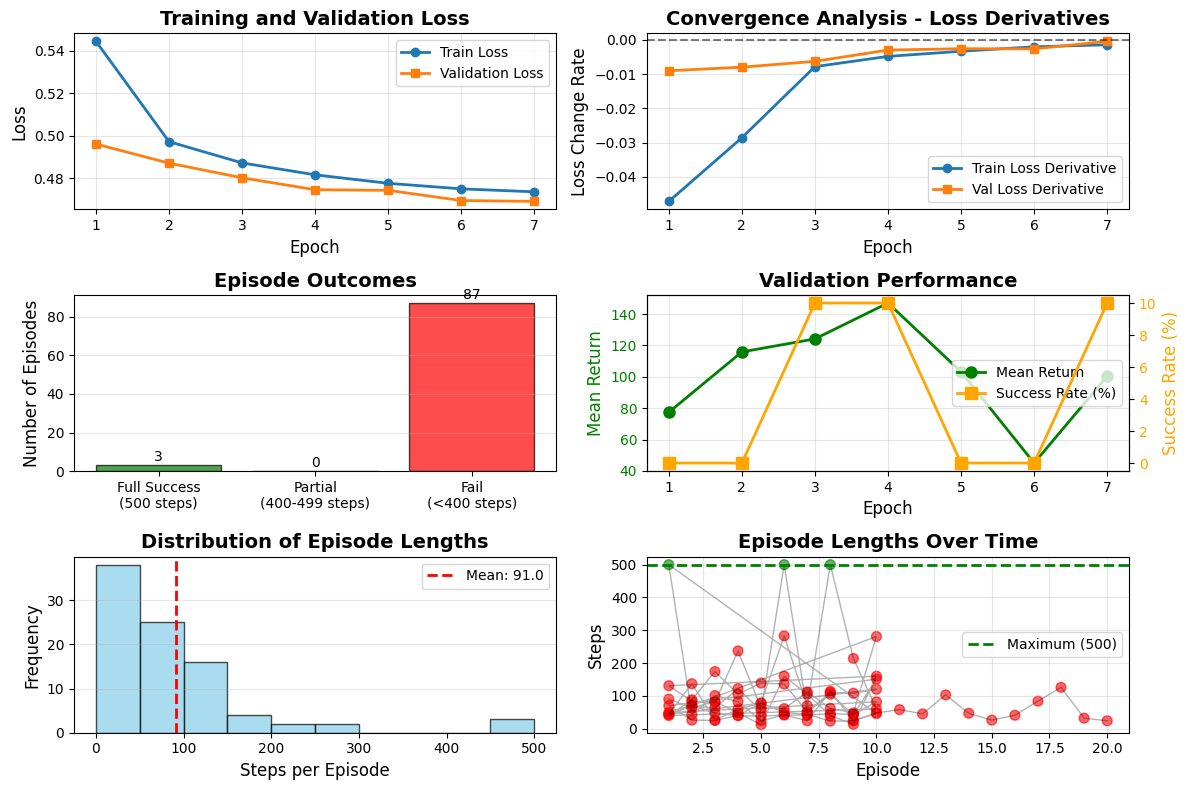

In [ ]:
from visualize_train_log import parse_training_log, plot_training_curves, print_results
log_file = '/content/train_baseline.log' # Путь к лог-файлу
epochs, val_results, val_episodes = parse_training_log(log_file) # Парсим данные
print_results(epochs, val_results, val_episodes) # Печатаем результаты
plot_training_curves(epochs, val_results, val_episodes, save_file = True, file_name_prefix='file') # Строим графики

### Validation

Model: n_embed=64, n_layer=3, n_head=4
Average reward: 54.20

Извлечено 5 эпизодов
Среднее вознаграждение: 54.20
Общее количество шагов: 266


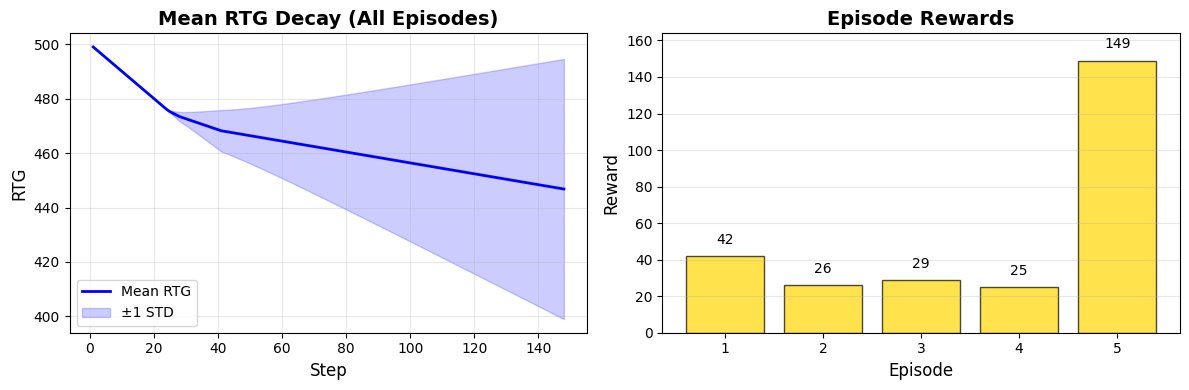

In [ ]:
from visualize_val_log import parse_log_file, plot_validation_curves, print_results
log_file = '/content/val_baseline.log' # Путь к лог-файлу
episodes = parse_log_file(log_file) # Парсим данные
print_results(episodes) # Печатаем результаты
plot_validation_curves(episodes) # Строим графики

## 2. DT+LSTM

### Train

Dataset: total=49811, train=44829, val=4982
State dim=2, Actions=2
Best model: models/memory_dt_velocity_cartpole_lstm_best.pt

Извлечено 6 эпох
Извлечено 80 валидационных эпизодов
Финальная тренировочная потеря: 0.4686
Финальная валидационная потеря: 0.4679
Финальное среднее вознаграждение: 500.00
Финальный процент успеха: 100.0%


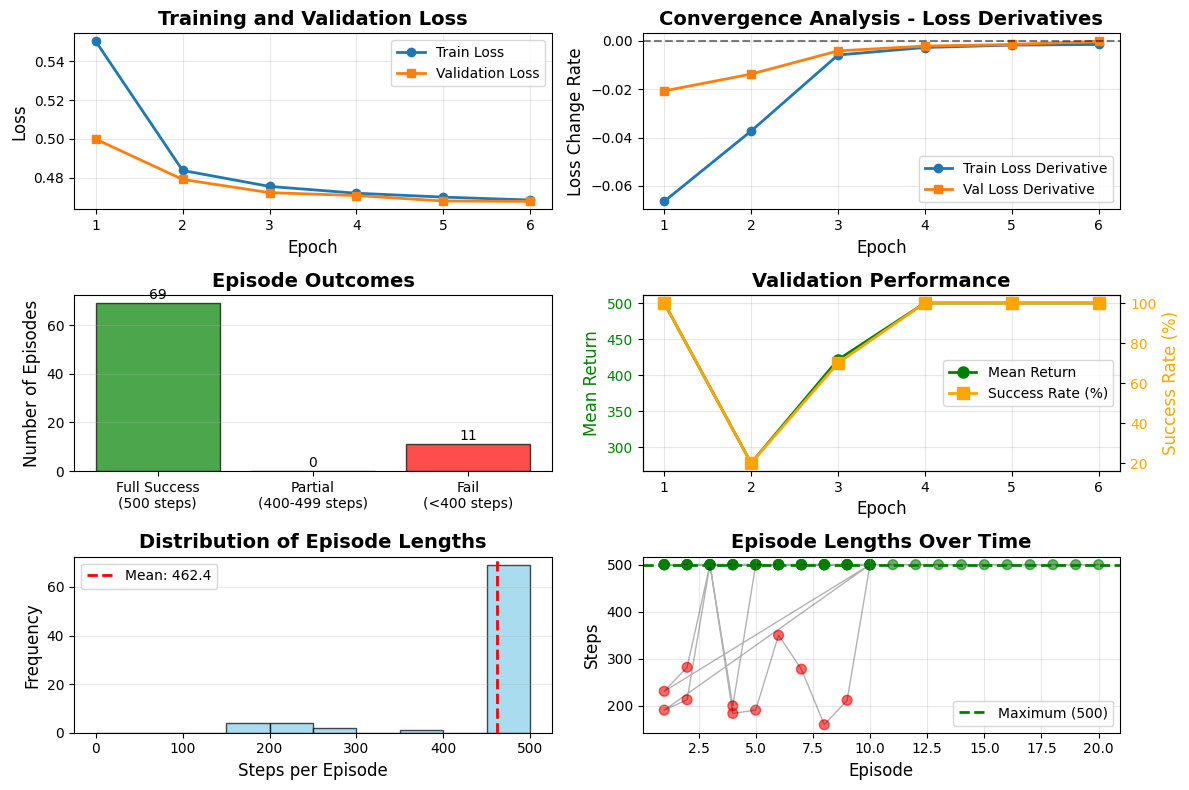

In [ ]:
from visualize_train_log import parse_training_log, plot_training_curves, print_results
log_file = '/content/lstm_train_baseline.log' # Путь к лог-файлу
epochs, val_results, val_episodes = parse_training_log(log_file) # Парсим данные
print_results(epochs, val_results, val_episodes) # Печатаем результаты
plot_training_curves(epochs, val_results, val_episodes) # Строим графики

### Validation

Model: n_embed=64, n_layer=3, n_head=4
Average reward: 500.00

Извлечено 5 эпизодов
Среднее вознаграждение: 500.00
Общее количество шагов: 2495


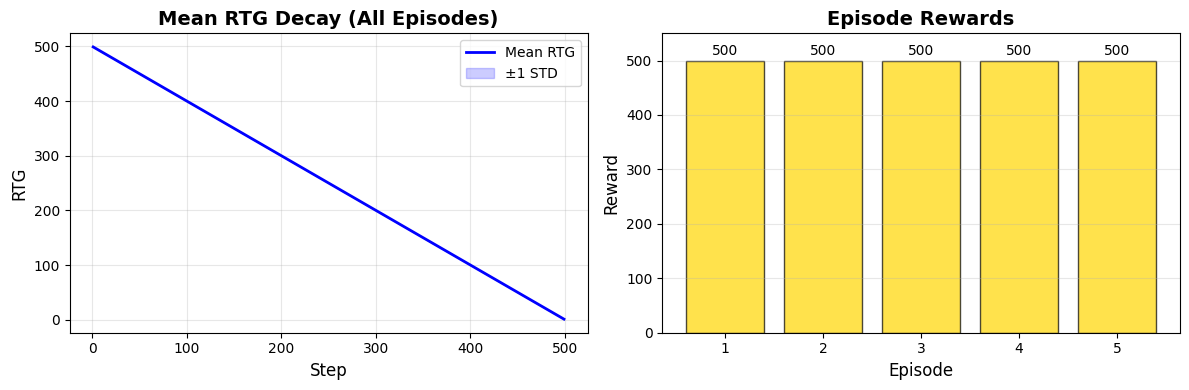

In [ ]:
from visualize_val_log import parse_log_file, plot_validation_curves, print_results
log_file = '/content/lstm_val_baseline.log' # Путь к лог-файлу
episodes = parse_log_file(log_file) # Парсим данные
print_results(episodes) # Печатаем результаты
plot_validation_curves(episodes) # Строим графики

## 3. DT+GRU

### Train

Dataset: total=49811, train=44829, val=4982
State dim=2, Actions=2
Best model: models/memory_dt_velocity_cartpole_gru_best.pt

Извлечено 6 эпох
Извлечено 80 валидационных эпизодов
Финальная тренировочная потеря: 0.4686
Финальная валидационная потеря: 0.4674
Финальное среднее вознаграждение: 500.00
Финальный процент успеха: 100.0%


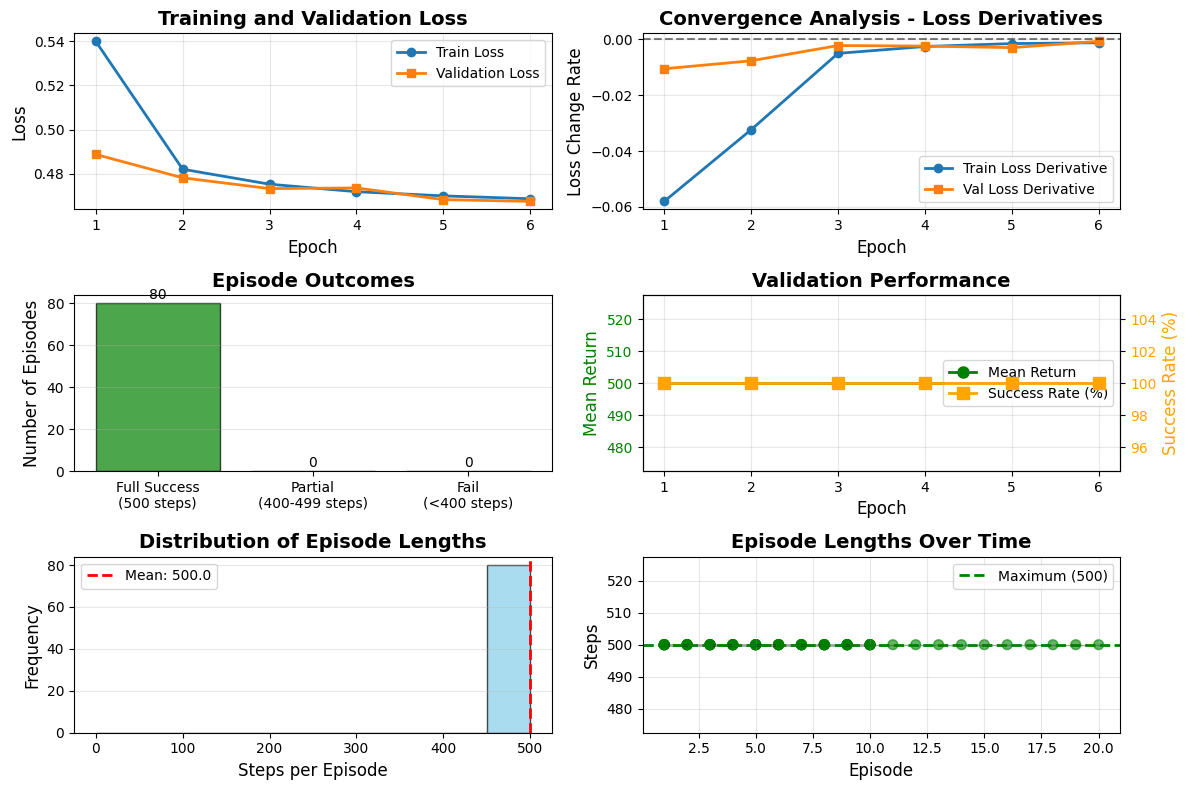

In [ ]:
from visualize_train_log import parse_training_log, plot_training_curves, print_results
log_file = '/content/gru_train_baseline.log' # Путь к лог-файлу
epochs, val_results, val_episodes = parse_training_log(log_file) # Парсим данные
print_results(epochs, val_results, val_episodes) # Печатаем результаты
plot_training_curves(epochs, val_results, val_episodes) # Строим графики


### Validation

Model: n_embed=64, n_layer=3, n_head=4
Average reward: 500.00

Извлечено 5 эпизодов
Среднее вознаграждение: 500.00
Общее количество шагов: 2495


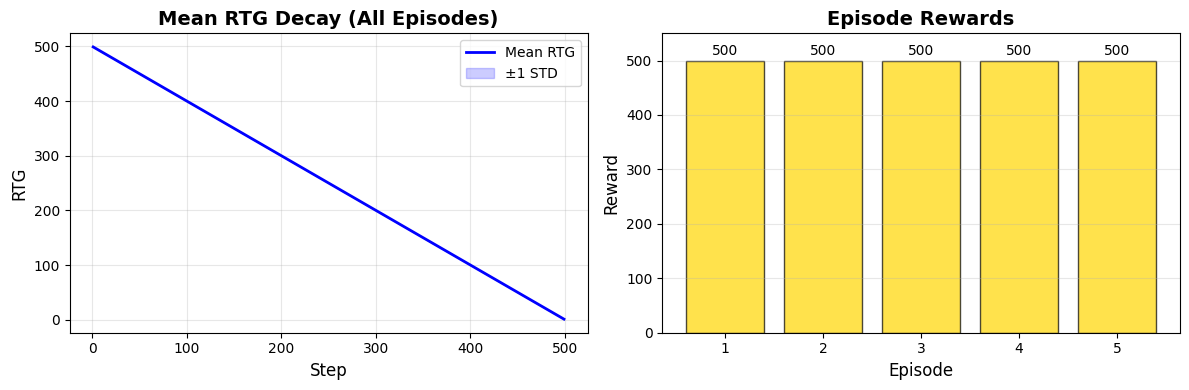

In [ ]:
from visualize_val_log import parse_log_file, plot_validation_curves, print_results
log_file = '/content/gru_val_baseline.log' # Путь к лог-файлу
episodes = parse_log_file(log_file) # Парсим данные
print_results(episodes) # Печатаем результаты
plot_validation_curves(episodes) # Строим графики

## Выводы:

Модели с DT+LSTM и DT+GRU демонстрируют более быструю сходимость, более высокий return и success rate по сравнению с DT. По последним характеристикам DT+GRU немного превосходит DT+LSTM.

DT модель демонстрирует малое количество успешных исходов игры. Большинство эпизодов имеют малую длину (в среднем 91). Это показатель не увеличивается со временем.
Финальное число успехов для обученной модели DT - 10 %.

Для модели DT+LSTM длина эпизодов в среднем значительно выше (462.4) и она увеличивается со временем. Доля успешных исходов больше.

Для модели DT+GRU (в данном прогоне) все эпизоды закончились успешно (100%)(длина эпизодов в среднем 500).
Финальное число успехов для обученных моделей DT+LSTM, DT+GRU, - 10 %.


На валидации для модели DT среднее вознаграждение составило 54.20.
На валидации для моделей DT+LSTM, DT+GRU среднее вознаграждение составило 500.

Модели DT+LSTM и DT+GRU более стабильно обучаются и дают лучшие результаты.



## Эксперименты

## DT

Попробуем увеличить длину контекста до 50.

In [ ]:
!python run_memory_dt.py --env velocity_cartpole --memory_type none --n_epochs 7 --eval_episodes 20 --context_length 50 2>&1 | tee train_baseline.log

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49721, train=44748, val=4973, state_dim=2, actions=2
Epoch 1/7 [Train]: 100%|██████████| 700/700 [12:26<00:00,  1.07s/it, loss=0.4735, avg_loss=0.5540, lr=0.000994]
Epoch 1/7: Train Loss=0.5540, Val Loss=0.4983
Running environment validation...
Episode 1: Return=22.0, Steps=22
Episode 2: Return=20.0, Steps=20
Episode 3: Return=18.0, Steps=18
Episode 4: Return=24.0, Steps=24
Episode 5: Return=18.0, Steps=18
Episode 6: Return=22.0, Steps=22
Episode 7: Return=70.0, Steps=70
Episode 8: Return=81.0, Steps=81
Episode 9: Return=66.0, Steps=66
Episode 10: Return=71.0, Steps=71
Validation: Mean Return=41.20, Success Rate=0.00%
New best model with return 41.20
Epoch 2/7 [Train]: 100%|██████████| 700/700 [12:33<00:00,  1.08s/it, loss=0.4421, avg_loss=0.5005, lr=0.000899]
Epoch 2/7: Train Loss=0.5005, Val Loss=0.4790
Running environment validation...
Episode 1: Return=32.0, Steps=32
Episode 2: Return=23.0, Steps=23
E

In [ ]:
!python utils/visualize_dt_agent.py --env velocity_cartpole --model_path models/memory_dt_velocity_cartpole_None_best.pt --memory_type none 2>&1 | tee val_baseline.log

error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
Model parameters: n_embed=64, n_layer=3, n_head=4, memory_dim=64
action_head structure: Linear
Visualizing velocity_cartpole agent from models/memory_dt_velocity_cartpole_None_best.pt
Memory type: none, Context length: 20

Episode 1/5
Target return: 500.0
Step 1: Initial action

### Train

Dataset: total=49721, train=44748, val=4973
State dim=2, Actions=2
Best model: models/memory_dt_velocity_cartpole_None_best.pt

Извлечено 6 эпох
Извлечено 80 валидационных эпизодов
Финальная тренировочная потеря: 0.4706
Финальная валидационная потеря: 0.4644
Финальное среднее вознаграждение: 24.00
Финальный процент успеха: 0.0%
Графики сохранены в файл: file_training_curves_analysis.png


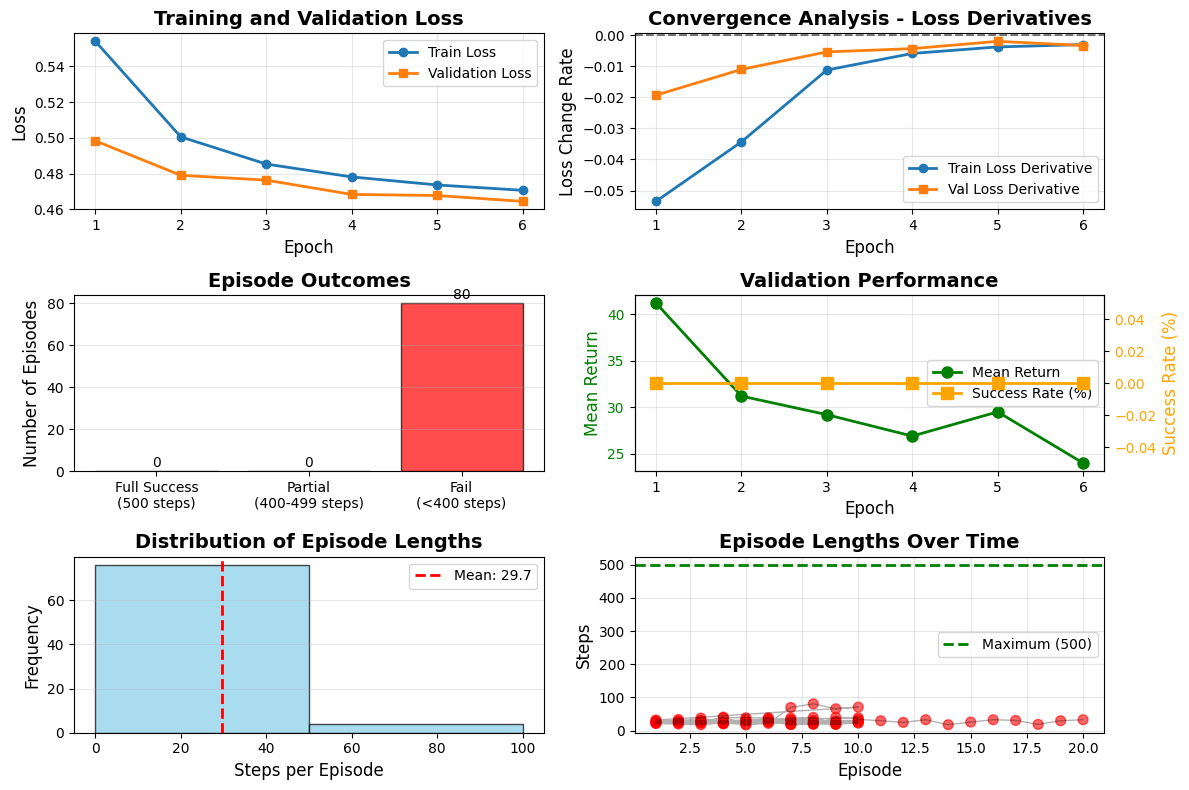

In [ ]:
from visualize_train_log import parse_training_log, plot_training_curves, print_results
log_file = '/content/train_baseline.log' # Путь к лог-файлу
epochs, val_results, val_episodes = parse_training_log(log_file) # Парсим данные
print_results(epochs, val_results, val_episodes) # Печатаем результаты
plot_training_curves(epochs, val_results, val_episodes, save_file = True, file_name_prefix='file') # Строим графики

### Validation

Model: n_embed=64, n_layer=3, n_head=4
Average reward: 30.20

Извлечено 5 эпизодов
Среднее вознаграждение: 30.20
Общее количество шагов: 146


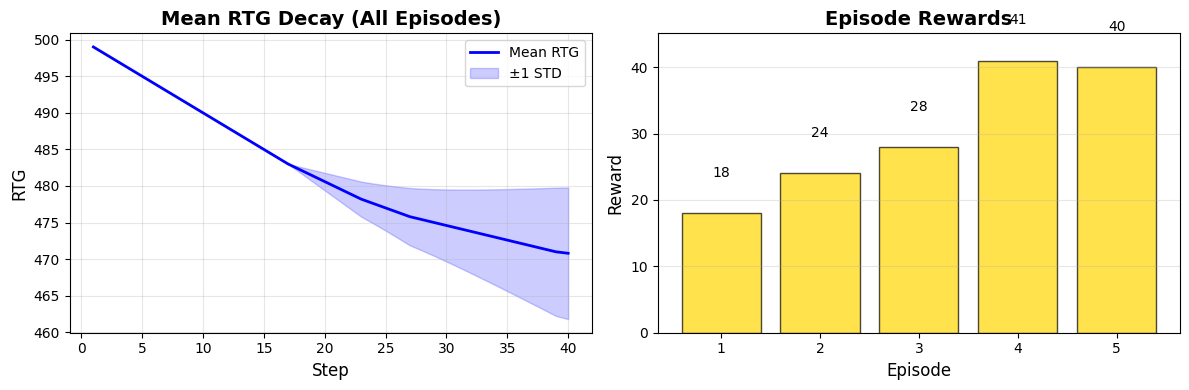

In [ ]:
from visualize_val_log import parse_log_file, plot_validation_curves, print_results
log_file = '/content/val_baseline.log' # Путь к лог-файлу
episodes = parse_log_file(log_file) # Парсим данные
print_results(episodes) # Печатаем результаты
plot_validation_curves(episodes) # Строим графики

Попробуем уменьшить длину контекста до 10.

In [ ]:
!python run_memory_dt.py --env velocity_cartpole --memory_type none --n_epochs 7 --eval_episodes 20 --context_length 10 2>&1 | tee train_baseline.log

Training Memory Decision Transformer on velocity_cartpole...
Dataset stats: total=49841, train=44856, val=4985, state_dim=2, actions=2
Epoch 1/7 [Train]: 100%|██████████| 701/701 [01:36<00:00,  7.24it/s, loss=0.5136, avg_loss=0.5637, lr=0.000994]
Epoch 1/7: Train Loss=0.5637, Val Loss=0.5091
Running environment validation...
Episode 1: Return=113.0, Steps=113
Episode 2: Return=110.0, Steps=110
Episode 3: Return=77.0, Steps=77
Episode 4: Return=127.0, Steps=127
Episode 5: Return=155.0, Steps=155
Episode 6: Return=165.0, Steps=165
Episode 7: Return=126.0, Steps=126
Episode 8: Return=143.0, Steps=143
Episode 9: Return=156.0, Steps=156
Episode 10: Return=199.0, Steps=199
Validation: Mean Return=137.10, Success Rate=0.00%
New best model with return 137.10
Epoch 2/7 [Train]: 100%|██████████| 701/701 [01:34<00:00,  7.40it/s, loss=0.5400, avg_loss=0.5032, lr=0.000898]
Epoch 2/7: Train Loss=0.5032, Val Loss=0.4786
Running environment validation...
Episode 1: Return=500.0, Steps=500
Episode 2: R

In [ ]:
!python utils/visualize_dt_agent.py --env velocity_cartpole --model_path models/memory_dt_velocity_cartpole_None_best.pt --memory_type none 2>&1 | tee val_baseline.log

error: XDG_RUNTIME_DIR not set in the environment.
ALSA lib confmisc.c:855:(parse_card) cannot find card '0'
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_card_inum returned error: No such file or directory
ALSA lib confmisc.c:422:(snd_func_concat) error evaluating strings
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_concat returned error: No such file or directory
ALSA lib confmisc.c:1334:(snd_func_refer) error evaluating name
ALSA lib conf.c:5178:(_snd_config_evaluate) function snd_func_refer returned error: No such file or directory
ALSA lib conf.c:5701:(snd_config_expand) Evaluate error: No such file or directory
ALSA lib pcm.c:2664:(snd_pcm_open_noupdate) Unknown PCM default
Model parameters: n_embed=64, n_layer=3, n_head=4, memory_dim=64
action_head structure: Linear
Visualizing velocity_cartpole agent from models/memory_dt_velocity_cartpole_None_best.pt
Memory type: none, Context length: 20

Episode 1/5
Target return: 500.0
Step 1: Initial action

### Train

Dataset: total=49841, train=44856, val=4985
State dim=2, Actions=2
Best model: models/memory_dt_velocity_cartpole_None_best.pt

Извлечено 7 эпох
Извлечено 90 валидационных эпизодов
Финальная тренировочная потеря: 0.4737
Финальная валидационная потеря: 0.4694
Финальное среднее вознаграждение: 500.00
Финальный процент успеха: 100.0%
Графики сохранены в файл: file_training_curves_analysis.png


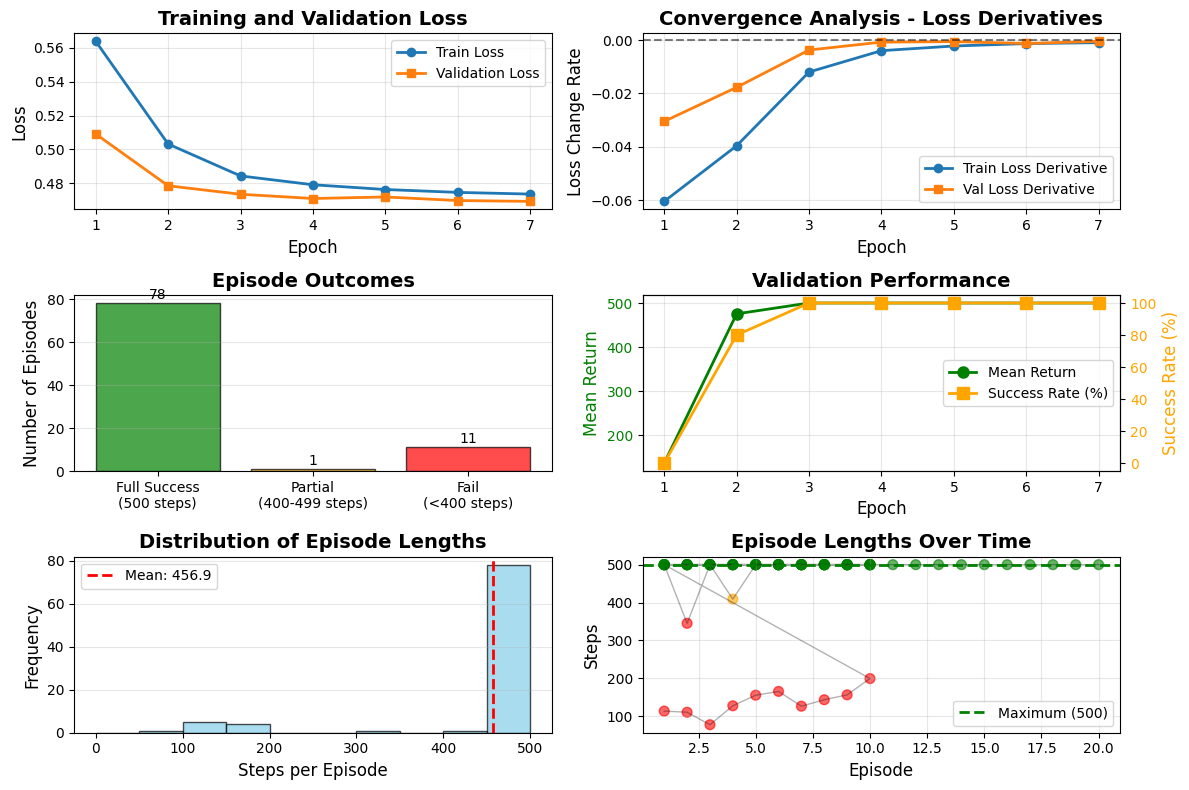

In [ ]:
from visualize_train_log import parse_training_log, plot_training_curves, print_results
log_file = '/content/train_baseline.log' # Путь к лог-файлу
epochs, val_results, val_episodes = parse_training_log(log_file) # Парсим данные
print_results(epochs, val_results, val_episodes) # Печатаем результаты
plot_training_curves(epochs, val_results, val_episodes, save_file = True, file_name_prefix='file') # Строим графики

### Validation

Model: n_embed=64, n_layer=3, n_head=4
Average reward: 44.40

Извлечено 5 эпизодов
Среднее вознаграждение: 44.40
Общее количество шагов: 217


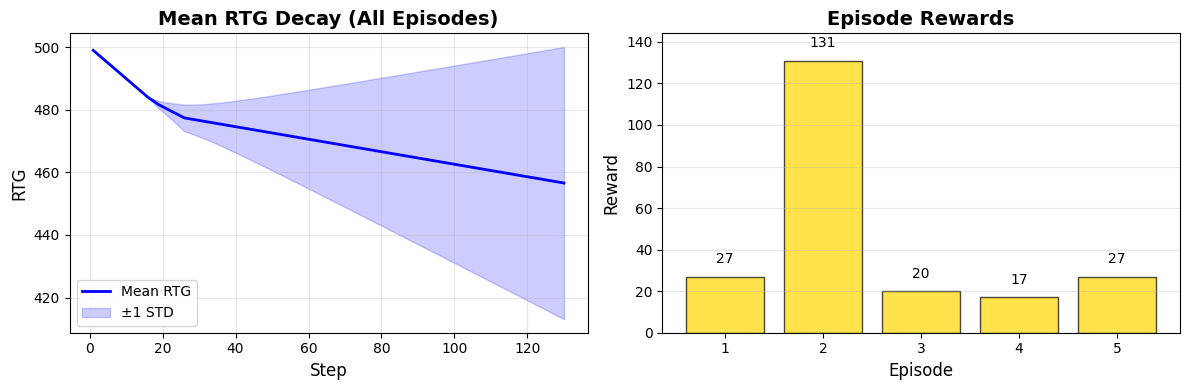

In [ ]:
from visualize_val_log import parse_log_file, plot_validation_curves, print_results
log_file = '/content/val_baseline.log' # Путь к лог-файлу
episodes = parse_log_file(log_file) # Парсим данные
print_results(episodes) # Печатаем результаты
plot_validation_curves(episodes) # Строим графики

## Выводы:

При увеличенной длине контекста (50) модель DT не обучается. Длинный контекст создает лишний "шум" и модель начинает путаться в удачных и неудачных паттернах поведения.

При более короткой длине контекста (10) модель показывает хорошие результаты на трейне, но на валидации проигрывает модели с длиной контекста 20. В этом случае модель переобучается.